# Does the market read the Waffle House Index? 🧇🌀
### FEMA gauges a storm by whether the always-open chain closes — but does Wall Street move the obvious stocks?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Index%3F: Busted](https://img.shields.io/badge/Index%3F-Busted-8b949e?style=flat-square)

There's a famous bit of disaster folklore: the **Waffle House Index**. The chain almost never closes, so FEMA uses it as a fast, on-the-ground severity gauge — *green* means full menu (mild), *yellow* means a limited menu (serious), *red* means the Waffle House actually shut its doors (catastrophic). It's real, and FEMA administrators have said so on the record.

Flip it into a market question. If a storm is bad enough to close a Waffle House, it's bad enough to matter to the two most *obviously* exposed corners of the stock market:

- **Property & casualty insurers** — Allstate, Travelers, Progressive — who write the checks. Their stocks should **dip**.
- **Home-improvement / rebuild names** — Home Depot, Lowe's — who sell the plywood, generators and drywall. Their stocks should **rally**.

That's the claim we test on **16 major US hurricanes since Katrina**. Do insurers drop? Do rebuilders pop? And could you have traded it?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the paired long-short test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from waffle_index import data, strategy as st

EVENTS = data.disaster_table()
HAVE_REAL = data.have_real()
PRE, POST, LO, HI = 10, 20, 0, 20
if HAVE_REAL:
    CLOSES = data.load_real()
    SPY = CLOSES["SPY"]
    AR_INS = st.basket_ar(CLOSES, data.INSURERS, SPY)
    AR_REB = st.basket_ar(CLOSES, data.REBUILDERS, SPY)
else:
    CLOSES = SPY = AR_INS = AR_REB = None
print("real cache present:", HAVE_REAL, "| hurricanes in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 16, 'cal_lo': '2005-08-29', 'cal_hi': '2024-10-09', 'ins_car': 1.15, 'ins_t': 1.48, 'ins_nw': 1.63, 'ins_down': 6, 'ins_down_pct': 37.5, 'ins_wilson': (18.5, 61.4), 'reb_car': -0.28, 'reb_t': -0.25, 'reb_nw': -0.37, 'reb_up': 8, 'reb_up_pct': 50.0, 'reb_wilson': (28.0, 72.0), 'ls_spread': -1.43, 'ls_t': -0.88, 'ls_nw': -1.06, 'ls_ci': (-4.32, 1.62), 'plc_ins_mean': 0.26, 'plc_ins_sd': 1.03, 'plc_ins_p': 0.385, 'plc_reb_mean': 0.28, 'plc_reb_sd': 1.31, 'plc_reb_p': 0.662, 'plc_ls_mean': 0.04, 'plc_ls_sd': 1.67, 'plc_ls_p': 0.379, 'offsets': [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'ins_path': [0.0, 0.0, 0.27, 0.47, 0.83, 0.26, 0.19, 0.37, -0.36, 0.05, 0.0, 0.09, 0.02, 0.23, 0.39, 0.22, 0.63, 0.64, 0.32, 0.65, 0.84, 1.3, 1.13, 1.55, 1.81, 2.27, 1.4, 0.93, 1.28, 1.23, 1.2], 'reb_path': [0.0, -0.1, 0.77, 0.83, 0.96, 0.98, 1.11, 1.28, 1.57, 1.28, 1.71, 1.35, 1.32, 1.65, 1.52, 1.34, 1.14, 1.26, 1.51, 2.06, 2.27, 1.46, 1.27, 1.35, 1.04, 0.78, 0.81, 0.92, 1.41, 1.57, 1.0], 'ins_m5_t': -2.77, 'tier3_n': 7, 'tier3_ins': -0.28, 'tier3_ins_t': -0.36, 'tier3_reb': 3.09, 'tier3_reb_t': 2.02, 'tier3_ls': 3.36, 'tier3_ls_t': 1.64, 'pre15_n': 5, 'pre15_ls': -0.03, 'pre15_t': -0.01, 'post15_n': 11, 'post15_ls': -2.06, 'post15_t': -1.0, 'timer': {5: (-57.8, -78.8, -0.82, 38), 10: (-22.2, -44.2, -0.41, 44), 20: (-153.3, -177.2, -1.22, 25)}, 'syn_null_mean': -0.12, 'syn_null_sd': 1.19, 'syn_null_fire': 2, 'syn_planted_t': 3.42, 'syn_planted_ins_t': -2.64, 'syn_planted_reb_t': 1.81, 'syn_planted_spread': 2.85, 'fp_spy': '06c89e09c7e9', 'fp_all': '3eba4d87a095', 'fp_trv': '1d9d0f43fbd0', 'fp_pgr': '9730d67197d9', 'fp_hd': '60093d13105c', 'fp_low': '73373520bb2e'}


real cache present: True | hurricanes in table: 16


## The answer first

| Question | Answer |
|---|---|
| Do insurers dip in the month after a big storm? | **No — the opposite, if anything.** ALL/TRV/PGR drift **+1.15%** (market-adjusted) — *up*, not down, and statistically nothing. |
| Do rebuilders rally? | **No.** HD/LOW come in at **-0.28%** — flat, wrong sign for the claim. |
| Does the folklore's long-short trade work? | **No — it loses.** Long rebuilders / short insurers is short the leg that drifts up and long the leg that goes nowhere; it loses money at every horizon we tried. |
| Why? | **The market already knew the storm was coming.** A hurricane is *forecast* for days — unlike a plane crash or a bank failure, there's no surprise left to trade by landfall. |

> A tidy, intuitive disaster-trade story — tested on the modern tape, and it doesn't show up.

## 1 · The claim

> *"A major hurricane is a huge, tangible cash-flow event. Insurers are about to pay out billions — sell them. Home-improvement stores are about to sell a mountain of rebuild supplies — buy them. The Waffle House Index says the storm is real; the trade writes itself."*

It's the most natural disaster trade a person can think of, and both legs have a genuine fundamental mechanism (real payouts, real reconstruction demand). The question isn't whether those things happen — they do — it's whether there's a **tradable abnormal move left** by the time the storm actually lands.

## 2 · So what?

If real and tradable, it would be a clean, mechanical event edge: a calendar of storms, two baskets, a market-neutral book. But there's an obvious catch that makes the prior *skeptical*: hurricanes are **forecast days in advance**. An efficient market can price the expected insurer losses and the expected rebuild demand *before* landfall — leaving nothing for the post-landfall trader. So we ask three things: do insurers actually dip, do rebuilders actually rally, and does the long-short trade pay after costs?

## 3 · How would we even know?

- **The calendar.** **16** major US hurricane landfalls from 2005-08-29 to 2024-10-09 — Katrina, Rita, Wilma, Ike, Sandy, Matthew, Harvey, Irma, Florence, Michael, Laura, Ida, Ian, Idalia, Helene, Milton (public NHC/NOAA landfall dates).
- **The comparison.** Each stock's move **minus the S&P's** same-day move (so we're measuring the *stock-specific* reaction, not "the market went up"), cumulated over the [−10..+20]-session window around landfall — wide on purpose, because the storm is forecast ahead.
- **The luck check.** Draw 16 random days instead, 20,000 times — how often does a random calendar produce a move this big?
- **The trade check.** Buy the rebuilders, short the insurers at the landfall close, hold a few weeks, pay costs, compare to zero.

## 4 · The teardown — let's actually look

**First, the headline.** Where do the two baskets end up in the month after a major storm (market-adjusted, so the S&P's own move is stripped out)?

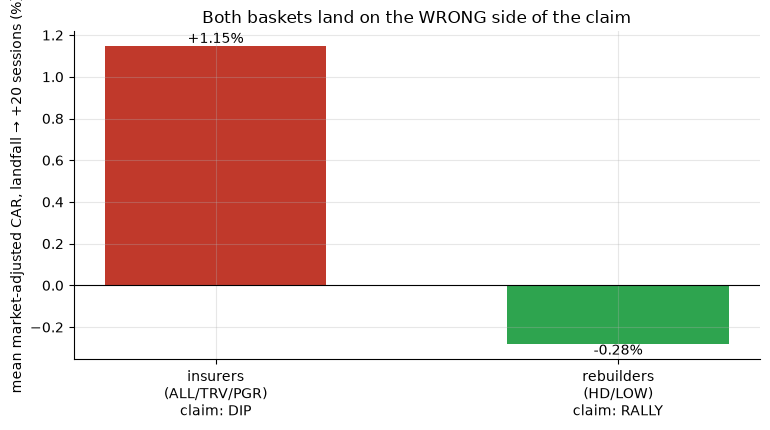

insurers +1.15% (claim: negative)  |  rebuilders -0.28% (claim: positive)


In [2]:
if HAVE_REAL:
    ins = st.car_stats(AR_INS, EVENTS['date'], PRE, POST, LO, HI)
    reb = st.car_stats(AR_REB, EVENTS['date'], PRE, POST, LO, HI)
    ins_c, reb_c = ins['mean'] * 100, reb['mean'] * 100
else:
    ins_c, reb_c = R['ins_car'], R['reb_car']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
bars = ax.bar(['insurers\n(ALL/TRV/PGR)\nclaim: DIP',
               'rebuilders\n(HD/LOW)\nclaim: RALLY'],
              [ins_c, reb_c], color=[RED, GREEN], width=.55)
for b, v in zip(bars, [ins_c, reb_c]):
    ax.annotate(f'{v:+.2f}%', (b.get_x() + b.get_width()/2, v), ha='center',
                va='bottom' if v >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean market-adjusted CAR, landfall → +20 sessions (%)')
ax.set_title('Both baskets land on the WRONG side of the claim')
plt.tight_layout(); plt.show()
print(f'insurers {ins_c:+.2f}% (claim: negative)  |  rebuilders {reb_c:+.2f}% (claim: positive)')

Insurers come in at **+1.15%** — *positive*, the wrong direction (a hardening-premium / "the uncertainty cleared" read beats the payout-panic read). Rebuilders are a flat **-0.28%**. Neither is anywhere near statistically meaningful. So much for the obvious trade.

**Next, the whole path.** Maybe the action is *before* landfall (the market front-running the forecast) rather than after?

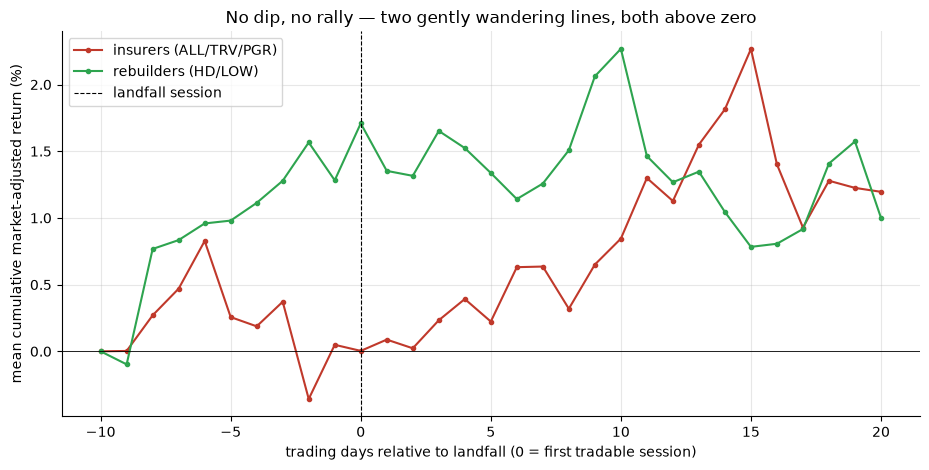

insurer CAR at +20: 1.2 %  | rebuilder CAR at +20: 1.0 %


In [3]:
if HAVE_REAL:
    cp_i = st.car_path_stats(AR_INS, EVENTS['date'], PRE, POST)
    cp_r = st.car_path_stats(AR_REB, EVENTS['date'], PRE, POST)
    ks = list(cp_i.index); ip = list(cp_i['car'] * 100); rp = list(cp_r['car'] * 100)
else:
    ks, ip, rp = R['offsets'], R['ins_path'], R['reb_path']
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.plot(ks, ip, '-o', color=RED, ms=3, label='insurers (ALL/TRV/PGR)')
ax.plot(ks, rp, '-o', color=GREEN, ms=3, label='rebuilders (HD/LOW)')
ax.axvline(0, c='k', lw=.8, ls='--', label='landfall session')
ax.axhline(0, c='k', lw=.6)
ax.set_xlabel('trading days relative to landfall (0 = first tradable session)')
ax.set_ylabel('mean cumulative market-adjusted return (%)')
ax.set_title('No dip, no rally — two gently wandering lines, both above zero')
ax.legend(); plt.tight_layout(); plt.show()
print('insurer CAR at +20:', round(ip[-1], 2), '%  | rebuilder CAR at +20:', round(rp[-1], 2), '%')

Neither line does what the story needs. There's no pre-landfall insurer *plunge* and no rebuilder *breakout* — just two noisy paths that both happen to drift slightly positive. The market has already digested the forecast by the time the storm arrives.

**Finally, the trade.** Long rebuilders, short insurers, entered at the landfall close — does the market-neutral book make money?

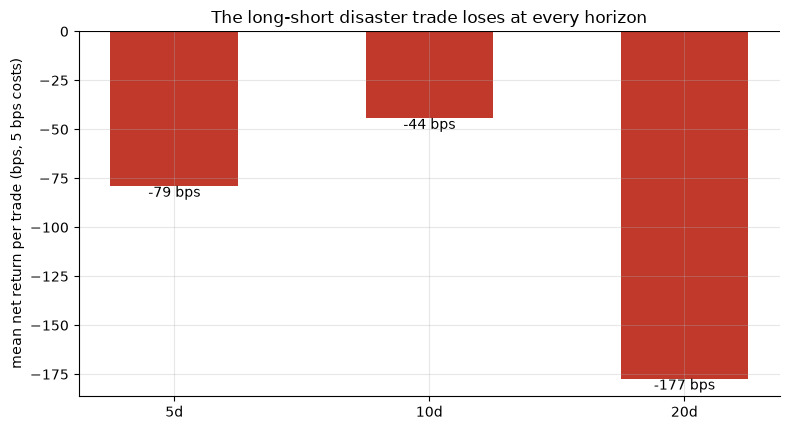

net (bps): {5: -78.8, 10: -44.2, 20: -177.2}


In [4]:
if HAVE_REAL:
    holds = [5, 10, 20]; nets = []
    for h in holds:
        lg = st.timer(CLOSES, EVENTS['date'], data.INSURERS, data.REBUILDERS,
                      hold=h, cost_bps=5.0)
        nets.append(st.summarize_trades(lg, 'ret_net')['mean_bps'])
else:
    holds = sorted(R['timer']); nets = [R['timer'][h][1] for h in holds]
fig, ax = plt.subplots(figsize=(8.0, 4.4))
b = ax.bar([f'{h}d' for h in holds], nets, color=RED, width=.5)
for bb, v in zip(b, nets):
    ax.annotate(f'{v:+.0f} bps', (bb.get_x()+bb.get_width()/2, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean net return per trade (bps, 5 bps costs)')
ax.set_title('The long-short disaster trade loses at every horizon')
plt.tight_layout(); plt.show()
print('net (bps):', dict(zip(holds, [round(v,1) for v in nets])))

Every holding period loses money — because the book is short the leg (insurers) that quietly drifts *up* and long the leg (rebuilders) that goes nowhere. There's no dip to short and no rally to ride.

## 5 · The verdict

- **Signal — None.** Insurers **+1.15%**, rebuilders **-0.28%** — both wrong-signed, neither significant, a random calendar reproduces them. The tidy dip/rally story isn't on the tape.
- **Tradability — Mirage.** The long-short trade loses at every horizon, before you even get to costs.
- **"Does the market read the Waffle House Index?" — Busted.** The storm is priced before it lands.

## 6 · Going further 🚪

- **This doesn't mean hurricanes are free for insurers.** A specific quarter's earnings absolutely take a hit — but that's *known and priced* by landfall, which is a different thing from a tradable post-event abnormal move in the stock.
- **Where a real version might live:** a single hard-hit *regional* insurer (not a diversified national), or a *homebuilder* rather than a big-box retailer, or the reinsurance / cat-bond market where the pricing actually moves — narrower instruments than the blunt large-cap baskets here.
- **Sibling studies:** [283-hurricane-season](../../283-hurricane-season/) (the seasonal calendar, not the event), [316-bank-failure](../../316-bank-failure/) and [707-plane-crash-effect](../../707-plane-crash-effect/) (the same event-study machinery on other disaster calendars).

*Think a narrower instrument catches what a large-cap basket misses? Show it — on out-of-sample storms, after costs — then we'll talk.*